# Кибербезопасность: геометрия эмбеддингов и кросс-источниковый перенос

Готовые наборы, где harmful и benign приходят из разных источников или в разной форме, разделяются
почти идеально уже мешком слов — то есть меряют шаблон и тему, а не вредоносность. Поэтому источники
здесь отобраны по измеренному критерию: внутри источника **оба класса приходят из одного пайплайна**,
а лексический бейзлайн на срезе не должен объяснять всю разделимость. Что именно отклонено и почему —
в следующей ячейке.

| источник | роль | на класс |
|---|---|---|
| **WildGuardMix adversarial** | основной, внутри источника | 611 |
| **WildJailbreak adversarial** | перенос | 611 |
| **Aegis 2.0 без шаблонов, выровнен по длине** | независимый тестовый | 139 |

Фактические значения BoW и длины считаются в самом блокноте (раздел про probe) — сверяться нужно
с ними, а не с цифрами отбора: там использовался обычный kfold, здесь — с группировкой по исходнику.

Три оговорки, которые нужно держать в голове при чтении результатов:

* **WildGuardMix и WildJailbreak — один фреймворк генерации (WildTeaming)** и пересекаются по текстам
  на ~30%. Совпадения удаляются (дословно и по TF-IDF ≥ 0.9), но даже после этого перенос между ними
  — это перенос **внутри одного фреймворка**, а не между независимыми источниками. Честный тест на
  независимость здесь только один: перенос на Aegis.
* **Aegis выровнен по длине, но не идеально.** Исходно benign там — длинные системные и ролевые
  промпты (медиана ~1000 символов), а unsafe — короткие запросы (~120), то есть разрыв был
  восьмикратным и часть разделимости объяснялась формой. После матчинга 1:1 по длине остаётся 139 пар
  на класс с медианами 1116 против 1450 — разрыв сократился до 1.3×, но не исчез, и короткие unsafe
  из выборки выпали. Бейзлайн длины на Aegis после этого нужно смотреть заново.
* **Это кибербезопасность, а не код.** Фильтр объединяет код и кибер-лексику, но доля подсреза «код»
  — около трети, и по выборочной проверке метка там в основном ложная (ролевые сюжеты, упоминающие
  скрипты). Настоящих запросов на написание кода в adversarial-частях почти нет, поэтому выводы про
  код-специфичные энкодеры нельзя переносить на code-домен вообще.

Разделы про расстояния, дисперсию, probe и FDR повторяют `RQ1.ipynb` и считаются отдельно по каждому
источнику.

# Какие ещё источники рассматривались и почему не подошли

Источники отбирались по измеряемому критерию: внутри источника **оба класса должны приходить из
одного пайплайна**, а лексический бейзлайн (BoW, 10-fold) на срезе «код ∪ кибербезопасность» не должен
превышать ~0.8. Если BoW уже разделяет классы почти идеально, то и probe на эмбеддингах разделит —
но измерит он шаблон и тему, а не вредоносность. Ниже всё, что проверялось и было отклонено.

## Отклонены: класс определяется шаблоном или формой

| источник | на класс | BoW | что именно выдаёт класс |
|---|---|---|---|
| **CyberSecEval** (MITRE vs FRR) | 750 / 750 | **1.00** | Два разных генератора. Слово «generate» — в 99% benign и 0% harmful (одно слово даёт accuracy 0.995); топ-5 начал покрывают 99% benign («Generate a C / Java / C++ / shell…»), у harmful — вводные-персоны («As a security…»). Плюс почти-дубликаты: у 27% benign есть сосед с TF-IDF ≥ 0.8 |
| **RMCBench × FalseReject** | 470 / 470 | **1.00** | Разные датасеты и разные формы: 95% benign заканчиваются на «?», у harmful — 0%; слово «code» даёт accuracy 0.968. Внутри RMCBench ещё и утечка между фолдами: все 100 jailbreak-промптов уровня 3 содержат тексты уровней 1–2, а 191 code-to-code промпт собран из 91 исходника |
| **WildJailbreak vanilla** | 549 / 1936 | **0.99** | 100% benign — вопросы, harmful — команды («?» у 100% против 12%) |
| **WildGuardMix vanilla** | 136 / 852 | **0.92** | benign мало, и это обычные вопросы про код («?» у 43% против 7%) |

Контроль длины в RMCBench не помогает: на подмножестве text-to-code уровней 1–2, где длины
сопоставимы с FalseReject, BoW всё равно 1.00 — мешает не длина, а форма «вопрос против команды».

## Отклонены: слишком мало данных в срезе про код

| источник | benign / harmful в срезе | почему |
|---|---|---|
| **ToxicChat** | 1095 / **25** | Реальные запросы пользователей, но токсичных про код почти нет |
| **OR-Bench** (80k и hard-1k против toxic) | 5130 / **12** | Токсичная часть маленькая, кибер-категории в ней нет |
| **Anthropic red team vs helpful-base** | **32** / 360 | Правильная постановка (один источник, разбиение по авторам), но benign про код почти нет |
| **AgentHarm, Cybercrime** | 24 / 24 | Настоящие пары harmful/benign по одному id, но это 6 базовых пар × 4 варианта: BoW 1.00, у 92% есть почти-дубликат |

## Отклонены: нет benign-стороны или не тот домен

| источник | почему |
|---|---|
| **PurpCode rl-safety-8k** | 8192 промпта, все harmful — benign-стороны нет вовсе |
| **Salad-Data** | Только harmful (base_set — вопросы, attack_enhanced — их jailbreak-обёртки) |
| **SafeSteer** | Пары safe/unsafe есть, но это описания сцен для генерации изображений; кибер-категорий нет |
| **CoCoNot**, **llm-refusal-evaluation** | Про код и кибербезопасность почти ничего |
| **RMCBench, CySecBench, MalwareBench, RedCode** (по отдельности) | Только harmful; benign пришлось бы брать из другого набора — то есть вернуться к проблеме из первой таблицы |

## Отклонено: сгенерированные benign-двойники

Отдельная попытка — построить недостающую benign-сторону самим: взять 630 настоящих harmful-запросов
на код (WildJailbreak + WildGuardMix, vanilla) и попросить LLM переписать каждый в безвредный близнец
с минимальной правкой. Получилось 389 пар, и они оказались непригодны:

* **BoW = 0.999.** После вырезания слов-маркеров (`own`, `authorized`, `consent`, `test`) и глаголов
  формы — всё ещё 0.998, то есть дело не в паре слов;
* **`my own` — в 90% benign и 0% harmful**, одно слово `own` даёт accuracy 0.983. Вредоносность
  снималась припиской-оправданием, а не сменой сути;
* **это не минимальные правки:** медиана TF-IDF-сходства внутри пары 0.03, у 98.5% пар < 0.2, пар со
  сходством ≥ 0.4 нет вообще. Модель писала benign-задачу заново;
* **дрейф формы:** 68% benign начинаются с «Write», у harmful — «Develop/Create».

Вывод по этой ветке: для кода намерение почти всегда лексично («keylogger для слежки» против
«keylogger своих нажатий» неизбежно отличается словами), поэтому двойники с по-настоящему незаметной
правкой получить трудно. Ветка отложена, а не закрыта: при ужесточении промта (требовать diff, а не
пересказ; запретить обезвреживание припиской; отбраковывать пары со сходством < 0.5) реалистичная
цель — BoW около 0.7–0.8, как у WildGuardMix, но не «незаметно».

## Что осталось

Прошли отбор три источника, они и используются в блокноте: **WildGuardMix adversarial**,
**WildJailbreak adversarial** и **Aegis 2.0 без шаблонов**. Из них только пара «WildTeaming-источник
против Aegis» независима — WildGuardMix и WildJailbreak сделаны одним фреймворком.

# Utility code

In [26]:
%pip install -q gliner2 polars torchmetrics

In [27]:
import getpass
import os

if "HF_TOKEN" not in os.environ:
    os.environ["HF_TOKEN"] = getpass.getpass("HF token: ")

In [28]:
import functools
import gc
import math
import random
import re
from abc import ABC, abstractmethod
from collections.abc import Callable, Sequence
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn.functional as F
from gliner2 import GLiNER2
from huggingface_hub import hf_hub_download, login
from huggingface_hub.utils import disable_progress_bars
from matplotlib.colors import LinearSegmentedColormap
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.model_selection import GroupKFold
from torchmetrics.functional.classification import binary_auroc
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer
from transformers.utils import logging as transformers_logging

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

generator = torch.Generator()
generator.manual_seed(42)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

login()
print(DEVICE)

cuda


In [29]:
class TextEmbedder(ABC):
    @abstractmethod
    def embed(self, texts: Sequence[str]) -> torch.Tensor:
        raise NotImplementedError

    def __call__(self, texts: Sequence[str]) -> torch.Tensor:
        return self.embed(texts)


class _TransformerEncoder(TextEmbedder):
    model_name: str
    # None — предел длины из конфигурации токенизатора; задаётся явно, если его там нет
    max_length: int | None = None

    def __init__(
            self,
            *,
            device: torch.device = DEVICE,
            batch_size: int = 64
    ) -> None:
        self.device = device
        self.batch_size = batch_size
        self.model = self._load_model().to(self.device).eval()
        self.tokenizer = self._load_tokenizer()

    def _load_model(self) -> torch.nn.Module:
        return AutoModel.from_pretrained(self.model_name)

    def _load_tokenizer(self):
        return AutoTokenizer.from_pretrained(self.model_name)

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return texts

    @abstractmethod
    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        raise NotImplementedError

    def embed(self, texts: Sequence[str]) -> torch.Tensor:
        texts = list(texts)
        if not texts:
            raise ValueError("The input sequence is empty.")

        texts = self._prepare_texts(texts)
        embeddings = []

        with torch.inference_mode():
            for start in range(0, len(texts), self.batch_size):
                batch = self.tokenizer(
                    texts[start:start + self.batch_size],
                    padding="longest",
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors="pt",
                )
                batch = {name: tensor.to(self.device) for name, tensor in batch.items()}
                embeddings.append(self._get_embeddings(batch).cpu())

        return torch.cat(embeddings, dim=0).T.contiguous()


class _MeanPoolingEmbedder(_TransformerEncoder):

    def _get_last_hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(**batch).last_hidden_state

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        last_hidden_state = self._get_last_hidden_state(batch)
        mask = batch["attention_mask"].unsqueeze(-1).to(last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)


class EttinEncoder68M(_MeanPoolingEmbedder):
    model_name = "jhu-clsp/ettin-encoder-68m"


class MmBertSmall(_MeanPoolingEmbedder):
    model_name = "jhu-clsp/mmBERT-small"


class E5SmallV2(_MeanPoolingEmbedder):
    model_name = "intfloat/e5-small-v2"

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return [f"query: {text}" for text in texts]


class LlamaPromptGuard2MeanPooler(_MeanPoolingEmbedder):
    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load_model(self) -> torch.nn.Module:
        return AutoModelForSequenceClassification.from_pretrained(self.model_name)

    def _get_last_hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model.deberta(**batch).last_hidden_state


class LlamaPromptGuard2_86M(_TransformerEncoder):
    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load_model(self) -> torch.nn.Module:
        return AutoModelForSequenceClassification.from_pretrained(self.model_name)

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        backbone_output = self.model.deberta(**batch)
        return self.model.pooler(backbone_output.last_hidden_state)


class GlinerGuardUniEncoder(_TransformerEncoder):
    model_name = "hivetrace/gliner-guard-uniencoder"

    def _load_model(self) -> torch.nn.Module:
        return GLiNER2.from_pretrained(self.model_name)

    def _load_tokenizer(self):
        return self.model.processor.tokenizer

    def _get_embeddings(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        # GLiNER2 — это nn.Module: трансформерный бэкбон лежит в .encoder, задачные головы
        # не используются, берётся то же mean pooling, что и у остальных моделей.
        last_hidden_state = self.model.encoder(**batch).last_hidden_state
        mask = batch["attention_mask"].unsqueeze(-1).to(last_hidden_state.dtype)
        return (last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)


class CodeBertBase(_MeanPoolingEmbedder):
    # RoBERTa, предобученный на парах код / естественный язык, без sentence-дообучения,
    # поэтому mean pooling, как у остальных. Позиционных эмбеддингов 514 — ограничиваем явно.
    model_name = "microsoft/codebert-base"
    max_length = 512


EMBEDDER_TYPES = {
    "ettin-encoder-68m": EttinEncoder68M,
    "mmBERT-small": MmBertSmall,
    "e5-small-v2": E5SmallV2,
    "Llama-Prompt-Guard-2-86M": LlamaPromptGuard2_86M,
    "Llama-Prompt-Guard-2-86M (mean pooler)": LlamaPromptGuard2MeanPooler,
    "gliner-guard-uniencoder": GlinerGuardUniEncoder,
    "codebert-base": CodeBertBase,
}

In [30]:
def describe(x: torch.Tensor, short: bool = False) -> dict[str, float]:
    x = x.detach().to(device=DEVICE, dtype=torch.float32)
    stat = {
        "mean": x.mean().item(),
        "std": x.std(unbiased=True).item(),
    }
    if short:
        return stat
    stat["25%"] = torch.quantile(x, 0.25).item()
    stat["50%"] = torch.quantile(x, 0.50).item()
    stat["75%"] = torch.quantile(x, 0.75).item()

    return stat


def display_table(
        statistic_method: Callable[..., dict[str, float | int]],
        name: str,
        stat_args_by_model: dict[str, tuple[Any, ...]] | None = None,
        **stat_args_by_group: dict[str, tuple[Any, ...]],
):
    if stat_args_by_model is not None:
        if not stat_args_by_model:
            raise ValueError("The input dictionary contains no models.")

        statistics_by_model = {
            model_name: statistic_method(*stat_args)
            for model_name, stat_args in stat_args_by_model.items()
        }
        table = pd.DataFrame.from_dict(statistics_by_model, orient="index")
        table.index.name = "embeddings"
        separator_selector = ""
    else:
        model_names = dict.fromkeys(
            model_name
            for args_by_model in stat_args_by_group.values()
            for model_name in args_by_model
        )
        if not model_names:
            raise ValueError("The input dictionaries contain no models.")

        statistics_by_model_and_group = {}
        for model_name in model_names:
            for group_name, stat_args in stat_args_by_group.items():
                statistics_by_model_and_group[(model_name, group_name)] = statistic_method(
                    *stat_args[model_name]
                )

        table = pd.DataFrame.from_dict(
            statistics_by_model_and_group,
            orient="index",
        )
        table.index = pd.MultiIndex.from_tuples(
            table.index,
            names=["embeddings", "group"],
        )

        separator_rows = [
            row_number
            for row_number, (previous, current) in enumerate(
                zip(table.index, table.index[1:]),
                start=2,
            )
            if previous[0] != current[0]
        ]
        separator_selector = ", ".join(
            f"tbody tr:nth-child({row}) > *"
            for row in separator_rows
        )

    formatters = {
        column: "{:d}" if pd.api.types.is_integer_dtype(table[column].dtype) else "{:.4f}"
        for column in table.columns
    }

    styles = [
        {
            "selector": "table",
            "props": [("border-collapse", "collapse")],
        },
        {
            "selector": "th, td",
            "props": [
                ("border", "1px solid #9aa5b1"),
                ("padding", "6px 10px"),
                ("text-align", "center"),
            ],
        },
        {
            "selector": "caption",
            "props": [
                ("font-weight", "bold"),
                ("text-align", "left"),
            ],
        },
    ]
    if separator_selector:
        styles.append({
            "selector": separator_selector,
            "props": [("border-top", "3px solid #4a5568")],
        })

    return (
        table
        .style
        .set_caption(name)
        .format(formatters)
        .background_gradient(cmap="Blues", axis=0)
        .set_table_styles(styles)
    )

In [31]:
def get_components_at_threshold(explained_variance: torch.Tensor, var_threshold: float = 0.9) -> int:
    cumulative_variance = explained_variance.cumsum(dim=0) / explained_variance.sum(dim=0)
    return int(torch.searchsorted(cumulative_variance, var_threshold).item()) + 1

# Датасеты и получение эмбеддингов

Во всех источниках берётся **один и тот же строгий фильтр** «код ∪ кибербезопасность», применённый
**симметрично к обоим классам**. Это важно: в первой версии этого блокнота benign отбирались по
кибер-лексике, а harmful — по подкатегории, и probe выучивал сам факт наличия термина. Дальше
промпты дедуплицируются, отбрасываются длиннее `MAX_PROMPT_CHARS`, классы уравниваются.

| источник | harmful | benign | фильтр стиля |
|---|---|---|---|
| WildGuardMix | `prompt_harm_label == "harmful"` | `unharmful` | только `adversarial` |
| WildJailbreak | `data_type == "adversarial_harmful"` | `adversarial_benign` | только adversarial; вычтены пересечения с WildGuardMix |
| Aegis 2.0 | `prompt_label == "unsafe"` | `safe` | выброшены промпты-шаблоны с `[TARGETLANGUAGE]` / `[PROMPT]` |

**Почему только adversarial** у первых двух: в vanilla-частях benign — это обычные вопросы (у
WildJailbreak 99% заканчиваются на «?» против 10% у harmful), и классы разделяются формой, а не
намерением. BoW там 0.92–0.99, то есть срез непригоден.

**Группировка для kfold.** В WildJailbreak один vanilla-исходник порождает до 12 adversarial-вариантов,
поэтому фолды режутся по исходнику: варианты одного сида не попадают одновременно в train и test.
У остальных источников такой связи нет, там группа — сама строка.

Доступ: WildGuardMix и WildJailbreak — gated на HuggingFace (нужен `HF_TOKEN` и принятые лицензии),
Llama-Prompt-Guard-2 — gated модель. Aegis 2.0 открыт.

In [32]:
MAX_PROMPT_CHARS = 15_000
# сколько промптов на класс брать в каждом источнике; None — сколько осталось после фильтров
SOURCE_SIZES = {
    "WildGuardMix": 611,
    "WildJailbreak": 611,
    "Aegis 2.0": None,   # определяется выравниванием по длине, см. match_by_length
}
# допуск при выравнивании Aegis по длине: benign там в разы длиннее harmful
AEGIS_LENGTH_TOLERANCE = 0.25
# сколько раз прогнать probe на перемешанных метках для нижней границы
SHUFFLE_REPEATS = 3
# None — брать SOURCE_SIZES; число — ограничить сверху для быстрого прогона
SAMPLE_LIMIT = None
FOLD_NUM = 10
VAR_THRESHOLD = 0.9
EMBEDDINGS_FILENAME = "embeddings_code_domain.pt"
# порог, выше которого промпт WildJailbreak считается дубликатом промпта WildGuardMix
CROSS_SOURCE_DUP = 0.9

SOURCE_NAMES = ("WildGuardMix", "WildJailbreak", "Aegis 2.0")
SOURCE_SHORT_NAMES = {"WildGuardMix": "WGM", "WildJailbreak": "WJB", "Aegis 2.0": "Aegis"}
# WildGuardMix и WildJailbreak сделаны одним фреймворком (WildTeaming)
SOURCE_FRAMEWORK = {"WildGuardMix": "WildTeaming", "WildJailbreak": "WildTeaming", "Aegis 2.0": "Aegis"}

# Творческие и не-программные употребления script/program, которые не должны считаться кодом.
CREATIVE_PATTERN = re.compile(
    r"\b(?:comedy|video|movie|film|play|tv|screen|youtube|podcast|stand-up|sketch|dialogue|"
    r"theat(?:er|re)|radio|speech|story|sales|marketing|interview|documentary|commercial|skit|"
    r"news|phone|call|narrative|role-?play)\s+scripts?\b"
    r"|\b(?:tv|radio|training|loyalty|educational|school|government|social|welfare|exercise|diet|"
    r"rehab\w*|mentorship|volunteer|outreach|reality|cooking|talk|news|degree|study|exchange|"
    r"internship|fitness|research|aid|assistance)\s+programs?\b"
)
CODE_PATTERN = re.compile(
    r"```|\bdef \w+\(|\bimport \w+|#include|<script|\bselect \* from\b|\bsudo |\bpython\b|"
    r"\bjava ?script\b|\bnode\.?js\b|\bc\+\+|\bc#|\bbash\b|\bpowershell\b|\bsql\b|\bhtml\b|\bphp\b|"
    r"\bapi\b|\bsource code\b|\bcode snippet\b|"
    r"\b(?:write|create|develop|generate|provide|give me)\s+(?:a |an |the |some )?(?:\w+ ){0,2}code\b|"
    r"\bcode (?:that|to|for)\b|\b(?:python|bash|shell|powershell|batch|php|javascript) script\b|"
    r"\bscript (?:that|to|which)\b|\b(?:computer|software) program\b|\bprogram (?:that|to|which)\b|"
    r"\b(?:browser extension|chrome extension|plugin|botnet|web scraper|scraper|keylogger)\b"
)
CYBER_PATTERN = re.compile(
    r"\bmalware\b|\bransomware\b|\bspyware\b|\bkeylogger\b|\btrojan\b|\brootkit\b|\bbotnet\b|"
    r"\bcomputer virus\b|\bshellcode\b|\bbackdoor\b|\breverse shell\b|\bzero[- ]day\b|\bcve-\d|"
    r"\bsql injection\b|\bxss\b|\bcross[- ]site script|\bcsrf\b|\bbuffer overflow\b|\bddos\b|"
    r"\bdos attack\b|\bbrute[- ]forc|\bprivilege escalation\b|\bpenetration test|\bpentest|"
    r"\bhack(?:ing)? into\b|\bhack (?:a|an|the|someone|my|his|her|their)\b|\bhackers?\b|"
    r"\b(?:ethical|computer|network|password|account|wifi|email) hacking\b|\bcyber ?attack|"
    r"\bcybersecurity\b|\b(?:security|software|system|network|zero-day|critical) vulnerabilit|"
    r"\bvulnerabilit(?:y|ies) in (?:the |a |an )?(?:\w+ )?(?:system|software|network|app|application|"
    r"website|server|code|firmware|browser|device|protocol)|\bexploit (?:a |the )?vulnerabilit|"
    r"\bfirewall\b|\bantivirus\b|\bpassword crack|\bcrack (?:a |the |someone's )?password|"
    r"\bphishing\b|\bspoof(?:ing|ed)? (?:email|ip|website|domain|caller|gps|mac|dns)"
)
# (?i) внутри паттерна: polars получает только строку, флаги re.IGNORECASE туда не доедут
AEGIS_TEMPLATE_PATTERN = re.compile(r"(?i)\[?TARGETLANGUAGE\]?|\[PROMPT\]")


def slice_tag(text: str) -> str:
    """code / cyber / other — строгий фильтр, одинаковый для обоих классов."""
    cleaned = CREATIVE_PATTERN.sub(" ", text.lower())
    if CODE_PATTERN.search(cleaned):
        return "code"
    if CYBER_PATTERN.search(cleaned):
        return "cyber"
    return "other"


def normalize(text: str) -> str:
    return re.sub(r"\s+", " ", text.strip().lower())

In [33]:
def prepare(frame: pl.DataFrame) -> pl.DataFrame:
    """Убирает пустые, слишком длинные и повторяющиеся промпты, размечает срез."""
    return (
        frame
        .filter(pl.col("prompt").is_not_null() & (pl.col("prompt").str.len_chars() <= MAX_PROMPT_CHARS))
        .unique(subset=["prompt"], keep="first", maintain_order=True)
        .with_columns(pl.col("prompt").map_elements(slice_tag, return_dtype=pl.String).alias("slice"))
        .filter(pl.col("slice") != "other")
    )


def balanced_take(benign: pl.DataFrame, harmful: pl.DataFrame, source_name: str) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Берёт из обоих классов ровно одинаковое число строк.

    Раньше классы усекались независимо, и если одного из них не хватало, выборка молча
    получалась несбалансированной (в Aegis выходило 166 против 167).
    """
    size = min(benign.height, harmful.height)
    configured = SOURCE_SIZES[source_name]
    if configured is not None:
        size = min(size, configured)
    if SAMPLE_LIMIT is not None:
        size = min(size, SAMPLE_LIMIT)
    return (
        benign.sample(n=size, shuffle=True, seed=SEED),
        harmful.sample(n=size, shuffle=True, seed=SEED),
    )


def match_by_length(
        benign: pl.DataFrame,
        harmful: pl.DataFrame,
        tolerance: float,
) -> tuple[pl.DataFrame, pl.DataFrame]:
    """Матчинг 1:1 по длине: к каждому harmful подбирается неиспользованный benign
    сопоставимой длины (в пределах ±tolerance).

    Нужно для Aegis: там benign — длинные системные и ролевые промпты (медиана ~1000
    символов), а unsafe — короткие запросы (~120). Без выравнивания часть разделимости
    объясняется формой, а не намерением, а Aegis здесь единственный независимый источник.
    Выравнивается всё распределение длин, а не только диапазон.
    """
    benign_lengths = benign["prompt"].str.len_chars().to_numpy()
    available = list(np.argsort(benign_lengths))
    benign_rows, harmful_rows = [], []

    for harmful_index, length in enumerate(harmful["prompt"].str.len_chars().to_numpy()):
        low, high = length * (1 - tolerance), length * (1 + tolerance)
        position = next(
            (i for i, index in enumerate(available) if low <= benign_lengths[index] <= high),
            None,
        )
        if position is None:
            continue
        benign_rows.append(available.pop(position))
        harmful_rows.append(harmful_index)

    return benign[benign_rows], harmful[harmful_rows]


def load_wildguardmix() -> tuple[pl.DataFrame, pl.DataFrame]:
    frame = pl.concat([
        pl.read_parquet(hf_hub_download("allenai/wildguardmix", path, repo_type="dataset"))
        .select("prompt", "prompt_harm_label", "adversarial")
        for path in ("train/wildguard_train.parquet", "test/wildguard_test.parquet")
    ])
    frame = frame.filter(pl.col("prompt_harm_label").is_not_null() & pl.col("adversarial"))
    frame = prepare(frame).with_columns(pl.col("prompt").alias("group"))

    benign = frame.filter(pl.col("prompt_harm_label") == "unharmful")
    harmful = frame.filter(pl.col("prompt_harm_label") == "harmful")
    return balanced_take(benign, harmful, "WildGuardMix")


def load_wildjailbreak(exclude: Sequence[str]) -> tuple[pl.DataFrame, pl.DataFrame]:
    """adversarial-часть WildJailbreak за вычетом всего, что совпадает с WildGuardMix.

    `exclude` — тексты WildGuardMix. Удаляются дословные совпадения и близкие
    (TF-IDF cosine >= CROSS_SOURCE_DUP): датасеты сделаны одним фреймворком и
    пересекаются, иначе перенос между ними был бы частично утечкой.
    """
    raw = pd.read_csv(
        hf_hub_download("allenai/wildjailbreak", "train/train.tsv", repo_type="dataset"),
        sep="\t",
        usecols=["vanilla", "adversarial", "data_type"],
    )
    raw = raw[raw["data_type"].isin(["adversarial_harmful", "adversarial_benign"])]
    # в TSV есть строки без adversarial-текста; в новых pandas строковый dtype хранит их как NA,
    # и astype(str) их НЕ превращает в "nan" — polars такие значения в строковую колонку не примет
    raw = raw.dropna(subset=["vanilla", "adversarial"])
    frame = prepare(pl.DataFrame({
        "prompt": raw["adversarial"].astype(str).tolist(),
        "group": raw["vanilla"].astype(str).tolist(),   # исходник: до 12 вариантов на сид
        "data_type": raw["data_type"].tolist(),
    }))

    excluded = {normalize(text) for text in exclude}
    frame = frame.filter(~pl.col("prompt").map_elements(lambda t: normalize(t) in excluded, return_dtype=pl.Boolean))

    vectorizer = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True).fit(list(exclude) + frame["prompt"].to_list())
    similarity = (vectorizer.transform(frame["prompt"].to_list()) @ vectorizer.transform(list(exclude)).T).max(axis=1)
    frame = frame.filter(pl.Series(np.asarray(similarity.todense()).ravel() < CROSS_SOURCE_DUP))

    benign = frame.filter(pl.col("data_type") == "adversarial_benign")
    harmful = frame.filter(pl.col("data_type") == "adversarial_harmful")
    return balanced_take(benign, harmful, "WildJailbreak")


def load_aegis() -> tuple[pl.DataFrame, pl.DataFrame]:
    raw = pd.concat([
        pd.read_json(hf_hub_download("nvidia/Aegis-AI-Content-Safety-Dataset-2.0", name, repo_type="dataset"))
        for name in ("train.json", "validation.json", "test.json")
    ], ignore_index=True)
    raw = raw[raw["prompt_label"].isin(["safe", "unsafe"])].dropna(subset=["prompt"])
    frame = pl.DataFrame({
        "prompt": raw["prompt"].astype(str).tolist(),
        "prompt_label": raw["prompt_label"].tolist(),
    })
    # промпты-шаблоны генераторов: в benign их много, и они дают лексическую подсказку
    frame = frame.filter(~pl.col("prompt").str.contains(AEGIS_TEMPLATE_PATTERN.pattern))
    frame = prepare(frame).with_columns(pl.col("prompt").alias("group"))

    benign = frame.filter(pl.col("prompt_label") == "safe")
    harmful = frame.filter(pl.col("prompt_label") == "unsafe")
    benign, harmful = match_by_length(benign, harmful, AEGIS_LENGTH_TOLERANCE)
    return balanced_take(benign, harmful, "Aegis 2.0")


BENIGN, HARMFUL = {}, {}
benign, harmful = load_wildguardmix()
BENIGN["WildGuardMix"], HARMFUL["WildGuardMix"] = benign, harmful
wgm_texts = benign["prompt"].to_list() + harmful["prompt"].to_list()
BENIGN["WildJailbreak"], HARMFUL["WildJailbreak"] = load_wildjailbreak(wgm_texts)
BENIGN["Aegis 2.0"], HARMFUL["Aegis 2.0"] = load_aegis()

# Порядок строк фиксирован: сначала весь benign, затем весь harmful. В этом же порядке
# лежат эмбеддинги, метки, группы и тексты.
TEXTS = {name: BENIGN[name]["prompt"].to_list() + HARMFUL[name]["prompt"].to_list() for name in SOURCE_NAMES}
LABELS = {
    name: np.r_[np.zeros(BENIGN[name].height), np.ones(HARMFUL[name].height)].astype(np.float32)
    for name in SOURCE_NAMES
}
GROUPS = {
    name: np.array(
        [f"benign::{g}" for g in BENIGN[name]["group"].to_list()]
        + [f"harmful::{g}" for g in HARMFUL[name]["group"].to_list()]
    )
    for name in SOURCE_NAMES
}

for name in SOURCE_NAMES:
    if BENIGN[name].height != HARMFUL[name].height:
        raise ValueError(f"{name}: классы не равны ({BENIGN[name].height} / {HARMFUL[name].height})")
    print(f"{name}: по {BENIGN[name].height} промптов на класс, "
          f"уникальных групп {len(set(GROUPS[name]))}")

WildGuardMix: по 611 промптов на класс, уникальных групп 1222
WildJailbreak: по 611 промптов на класс, уникальных групп 1160
Aegis 2.0: по 139 промптов на класс, уникальных групп 278


In [34]:
def describe_prompts(prompts: pl.DataFrame) -> dict[str, float | int]:
    lengths = prompts["prompt"].str.len_chars()
    return {
        "prompts": prompts.height,
        "chars (median)": float(lengths.median()),
        "chars (p90)": float(lengths.quantile(0.9)),
        "share code slice": float((prompts["slice"] == "code").mean()),
        "ends with '?'": float(prompts["prompt"].str.strip_chars().str.ends_with("?").mean()),
    }


display_table(
    describe_prompts,
    "Prompts by source",
    benign={name: (BENIGN[name],) for name in SOURCE_NAMES},
    harmful={name: (HARMFUL[name],) for name in SOURCE_NAMES},
)

## Расчет эмбеддингов

In [35]:
def get_embeddings(filename: str = EMBEDDINGS_FILENAME) -> dict[str, dict[str, dict[str, torch.Tensor]]]:
    try:
        embeddings = torch.load(filename, weights_only=True)
    except FileNotFoundError:
        print("Getting embeddings from scratch...")
        embeddings = {}

    for model_name, embedder_type in EMBEDDER_TYPES.items():
        by_source = embeddings.setdefault(model_name, {})
        # кэш от выборки другого размера пересчитывается
        pending = [
            source_name for source_name in SOURCE_NAMES
            if source_name not in by_source
            or by_source[source_name]["benign"].shape[1] != BENIGN[source_name].height
            or by_source[source_name]["harmful"].shape[1] != HARMFUL[source_name].height
        ]
        if not pending:
            print(f"Embeddings for {model_name} are already computed")
            continue

        print(f"Loading {model_name}...")
        if model_name.startswith("Llama-Prompt-Guard-2"):
            embedder = embedder_type(batch_size=1)
        else:
            embedder = embedder_type(batch_size=4)

        for source_name in pending:
            print(f"Getting embeddings: {source_name}...")
            benign = embedder(BENIGN[source_name]["prompt"])
            harmful = embedder(HARMFUL[source_name]["prompt"])
            by_source[source_name] = {
                "benign": benign,
                "harmful": harmful,
                "all": torch.cat((benign, harmful), dim=1),
            }
            torch.save(embeddings, filename)

        del embedder
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        print()

    return embeddings


disable_progress_bars()
transformers_logging.disable_progress_bar()
transformers_logging.set_verbosity_error()

EMBEDDINGS = get_embeddings()

Loading ettin-encoder-68m...
Getting embeddings: Aegis 2.0...

Loading mmBERT-small...
Getting embeddings: Aegis 2.0...

Loading e5-small-v2...
Getting embeddings: Aegis 2.0...

Loading Llama-Prompt-Guard-2-86M...
Getting embeddings: Aegis 2.0...

Loading Llama-Prompt-Guard-2-86M (mean pooler)...
Getting embeddings: Aegis 2.0...

Loading gliner-guard-uniencoder...
🧠 Model Configuration
Encoder model      : bogdanminko/mmBERT-small
Counting layer     : count_lstm_v2
Token pooling      : first
Getting embeddings: Aegis 2.0...

Loading codebert-base...
Getting embeddings: Aegis 2.0...



# Общая информация

In [36]:
def describe_embeddings(embeddings: torch.Tensor) -> dict[str, int]:
    return {
        "embeddings' dim": embeddings.shape[0],
        "number of samples": embeddings.shape[1],
        "mean l2-norm": embeddings.norm(p=2, dim=0).mean().item(),
    }


display_table(
    describe_embeddings,
    "Embeddings",
    **{
        f"{SOURCE_SHORT_NAMES[source_name]} · {class_name}": {
            embedder: (EMBEDDINGS[embedder][source_name][class_name],) for embedder in EMBEDDER_TYPES
        }
        for source_name in SOURCE_NAMES
        for class_name in ("benign", "harmful")
    },
)

# Среднее и расстояния

In [37]:
def cos_similarity(x: torch.Tensor, y: torch.Tensor, dim: int = 0) -> torch.Tensor:
    x_norm = F.normalize(x, p=2, dim=dim)
    y_norm = F.normalize(y, p=2, dim=dim)

    return (x_norm * y_norm).sum(dim=dim)


def describe_mean_cos_distance(
        x: torch.Tensor,
        y: torch.Tensor,
        same_sample: bool = False,
        n: int = 100
) -> dict[str, float]:
    runs = []
    for _ in range(n):
        rand_perm = torch.randperm(x.shape[1], device=x.device)
        sample_size = rand_perm.shape[0]
        sample_x = x[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        if same_sample:
            # при нечётном числе примеров вторая половина на один длиннее — обрезаем до размера первой
            sample_y = y[:, rand_perm[int(sample_size // 2):2 * int(sample_size // 2)]].to(device=DEVICE)
        else:
            sample_y = y[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)

        runs.append(1 - cos_similarity(sample_x, sample_y).mean())

    return describe(torch.tensor(runs), short=True)


def describe_mean_l2_distance(
        x: torch.Tensor,
        y: torch.Tensor,
        same_sample: bool = False,
        n: int = 100,
) -> dict[str, float]:
    runs = []
    for _ in range(n):
        rand_perm = torch.randperm(x.shape[1], device=x.device)
        sample_size = rand_perm.shape[0]
        sample_x = x[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        if same_sample:
            # при нечётном числе примеров вторая половина на один длиннее — обрезаем до размера первой
            sample_y = y[:, rand_perm[int(sample_size // 2):2 * int(sample_size // 2)]].to(device=DEVICE)
        else:
            sample_y = y[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)

        runs.append((sample_x - sample_y).norm(p=2, dim=0).mean())

    return describe(torch.tensor(runs), short=True)


def calc_distance_ratio(x: torch.Tensor, y: torch.Tensor) -> dict[str, float]:
    x_center = x.mean(dim=1, keepdim=True)
    x_within_class_cos = describe_mean_cos_distance(x, x, same_sample=True)["mean"]
    x_within_class_l2 = describe_mean_l2_distance(x, x, same_sample=True)["mean"]

    y_center = y.mean(dim=1, keepdim=True)
    y_within_class_cos = describe_mean_cos_distance(y, y, same_sample=True)["mean"]
    y_within_class_l2 = describe_mean_l2_distance(y, y, same_sample=True)["mean"]

    return {
        "cosine": (2 * (1 - cos_similarity(x_center, y_center)) / (x_within_class_cos + y_within_class_cos)).item(),
        "L2": (2 * (x_center - y_center).norm(p=2) / (x_within_class_l2 + y_within_class_l2)).item()
    }

Пар benign ↔ harmful здесь нет, поэтому `within_pair` из RQ1 не считается. Три отдельные таблицы
расстояний (внутри классов и между ними) убраны: из них следовал ровно один вывод — классы
перекрываются. Он полностью виден в отношении ниже: расстояние между центрами классов, делённое на
среднее внутриклассовое. Значение около нуля означает, что центры лежат внутри облаков друг друга.

In [38]:
display_table(
    calc_distance_ratio,
    "Distance between class centers / mean within-class distance",
    **{
        source_name: {
            embedder: (EMBEDDINGS[embedder][source_name]["benign"], EMBEDDINGS[embedder][source_name]["harmful"])
            for embedder in EMBEDDER_TYPES
        }
        for source_name in SOURCE_NAMES
    },
)

# Дисперсия

In [39]:
def get_pca_decomposition(embeddings: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    num_samples = embeddings.shape[1]
    embeddings_cnt = (embeddings - embeddings.mean(dim=1, keepdim=True))
    cov = (embeddings_cnt @ embeddings_cnt.T) / (num_samples - 1)
    values, vectors = torch.linalg.eigh(cov)
    return values.flip(0), vectors.flip(1)


def calc_pca_subspace_overlap(group_a: torch.Tensor, group_b: torch.Tensor, var_threshold: float = 0.9) -> dict[
    str, int | float]:
    group_a_values, group_a_vectors = get_pca_decomposition(group_a)
    group_b_values, group_b_vectors = get_pca_decomposition(group_b)

    group_a_dim = get_components_at_threshold(group_a_values, var_threshold)
    group_b_dim = get_components_at_threshold(group_b_values, var_threshold)

    a_basis = group_a_vectors[:, :group_a_dim]
    b_basis = group_b_vectors[:, :group_b_dim]

    if group_a_dim < group_b_dim:
        projection = b_basis.T @ a_basis
    else:
        projection = a_basis.T @ b_basis

    singular_values = torch.linalg.svdvals(projection).flatten()

    return {
        "first subspace dim": group_a_dim,
        "second subspace dim": group_b_dim,

        # средняя доля квадрата длины вектора, сохраняющаяся при проекции:
        # 0 — пространства ортогональны, 1 — полностью совпадают
        "subspace overlap": ((singular_values ** 2).sum() / min(group_a_dim, group_b_dim)).item(),

        # то же для двух случайных подпространств тех же размерностей: max(dim) / d.
        # overlap имеет смысл сравнивать с этим уровнем, а не с нулём
        "chance overlap": max(group_a_dim, group_b_dim) / group_a.shape[0],
    }

Спектры PCA убраны: 21 панель, а вывод из них ограничен размером выборки. Ниже только таблица
перекрытия подпространств, в которой та же информация в сравнимом виде.

В каждом классе несколько сотен промптов, поэтому ранг ковариации ограничен размером выборки: число
компонент на 90% дисперсии зависит от размера источника, и между источниками его сравнивать нельзя
(Aegis в несколько раз меньше остальных). Сравнивать `subspace overlap` нужно с колонкой
`chance overlap` — это тот же показатель для двух случайных подпространств тех же размерностей.

In [40]:
display_table(
    functools.partial(calc_pca_subspace_overlap, var_threshold=VAR_THRESHOLD),
    f"Overlap at {VAR_THRESHOLD * 100:.0f}% of explained variance",
    **{
        source_name: {
            embedder: (EMBEDDINGS[embedder][source_name]["benign"], EMBEDDINGS[embedder][source_name]["harmful"])
            for embedder in EMBEDDER_TYPES
        }
        for source_name in SOURCE_NAMES
    },
)

# Linear Probe внутри источника

In [41]:
def train_linear_probe(
        x: torch.Tensor,
        y: torch.Tensor,
        val_frac: float = 0.1,
        lr: float = 1e-3,
        tol: float = 1e-5,
        early_stopping_iters: int = 100,
        max_iter_num: int = 10_000,
) -> torch.nn.Module:
    n = x.shape[0]
    val_size = int(n * val_frac)
    val_x = x[:val_size, :].to(device=DEVICE)
    val_y = y[:val_size, :].to(device=DEVICE)
    train_x = x[val_size:, :].to(device=DEVICE)
    train_y = y[val_size:, :].to(device=DEVICE)

    linear = torch.nn.Linear(train_x.shape[1], 1, device=DEVICE)
    optimizer = torch.optim.AdamW(linear.parameters(), lr=lr)

    best_val_loss = torch.inf
    best_state = None
    iterations_without_improvement = 0

    for i in range(1, max_iter_num + 1):
        linear.train()
        optimizer.zero_grad()
        train_loss = F.binary_cross_entropy_with_logits(linear(train_x), train_y)
        train_loss.backward()
        optimizer.step()

        linear.eval()
        with torch.no_grad():
            val_loss = F.binary_cross_entropy_with_logits(linear(val_x), val_y).item()

        if best_val_loss - val_loss > tol:
            best_val_loss = val_loss
            best_state = {
                name: value.detach().clone()
                for name, value in linear.state_dict().items()
            }
            iterations_without_improvement = 0
        else:
            iterations_without_improvement += 1
            if iterations_without_improvement >= early_stopping_iters:
                break

    if best_state is not None:
        linear.load_state_dict(best_state)

    return linear


def make_folds(source_name: str, fold_num: int = FOLD_NUM) -> list[tuple[np.ndarray, np.ndarray]]:
    """Фолды с группировкой: варианты одного vanilla-исходника не разъезжаются по фолдам.

    У WildJailbreak группа — исходный vanilla-промпт (до 12 adversarial-вариантов на сид);
    у остальных источников группа — сам промпт, то есть обычный kfold.
    """
    groups = GROUPS[source_name]
    splitter = GroupKFold(n_splits=fold_num)
    return list(splitter.split(np.zeros(len(groups)), groups=groups))


FOLDS = {name: make_folds(name) for name in SOURCE_NAMES}
BOW_TOKEN_PATTERN = r"\w(?:\S*\w)?|[^\w\s]"
BASELINES = ("BoW", "prompt len")
FEATURE_SETS = (*EMBEDDER_TYPES, *BASELINES)
# prompt len участвует только внутри источника: направление по длине выучивается неустойчиво
# (AUROC внутри WildGuardMix ~0.5), поэтому его знак при переносе случаен, а цифры невоспроизводимы
TRANSFER_FEATURE_SETS = (*EMBEDDER_TYPES, "BoW")


def source_matrix(feature_set: str, source_name: str) -> torch.Tensor | None:
    """Плотная матрица (n, d) для энкодера; None для текстовых бейзлайнов."""
    if feature_set in BASELINES:
        return None
    groups = EMBEDDINGS[feature_set][source_name]
    return torch.cat([groups["benign"], groups["harmful"]], dim=1).T.contiguous()


def fold_features(feature_set: str, source_name: str, train_idx: np.ndarray, test_idx: np.ndarray,
                  dense: torch.Tensor | None) -> tuple[torch.Tensor, torch.Tensor]:
    texts = TEXTS[source_name]
    if feature_set == "BoW":
        # словарь строится только по train-фолду
        vectorizer = CountVectorizer(token_pattern=BOW_TOKEN_PATTERN, lowercase=False, dtype=np.float32)
        train_x = torch.from_numpy(vectorizer.fit_transform([texts[i] for i in train_idx]).toarray())
        test_x = torch.from_numpy(vectorizer.transform([texts[i] for i in test_idx]).toarray())
        return train_x, test_x
    if feature_set == "prompt len":
        lengths = np.array([len(text) for text in texts], dtype=np.float32)
        return torch.from_numpy(lengths[train_idx]).unsqueeze(-1), torch.from_numpy(lengths[test_idx]).unsqueeze(-1)
    return dense[train_idx], dense[test_idx]


def describe_in_source(feature_set: str, source_name: str, shuffle_seed: int | None = None) -> dict[str, float]:
    folds = FOLDS[source_name]
    labels = LABELS[source_name]
    if shuffle_seed is not None:
        # нижняя граница: те же признаки и те же фолды, но метки перемешаны
        labels = np.random.default_rng(shuffle_seed).permutation(labels)
    dense = source_matrix(feature_set, source_name)

    auroc = torch.zeros(len(folds))
    accuracy = torch.zeros(len(folds))
    for i, (train_idx, test_idx) in enumerate(folds):
        train_x, test_x = fold_features(feature_set, source_name, train_idx, test_idx, dense)
        train_y = torch.from_numpy(labels[train_idx]).unsqueeze(-1)
        test_y = torch.from_numpy(labels[test_idx]).unsqueeze(-1)

        # train_linear_probe берёт валидацию из первых 10% строк, поэтому перемешиваем
        perm = torch.randperm(train_x.shape[0])
        probe = train_linear_probe(train_x[perm].contiguous(), train_y[perm].contiguous()).eval()

        with torch.no_grad():
            test_logits = probe(test_x.to(device=DEVICE))
            test_y = test_y.to(device=DEVICE)

        auroc[i] = binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item()
        accuracy[i] = ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item()

    return {
        "auroc (mean)": auroc.mean().item(),
        "auroc (std)": auroc.std().item(),
        "accuracy (mean)": accuracy.mean().item(),
        "accuracy (std)": accuracy.std().item(),
    }

Эмбеддинги и бейзлайны стоят в одной таблице: `BoW` — probe на мешке слов, `prompt len` — probe на
длине промпта в символах. Если бейзлайн близок к эмбеддингам, высокий AUROC внутри источника ничего
не говорит о семантике: его объясняют лексика или длина.

У бейзлайна `prompt len` смотрите только AUROC: probe учится на ненормированной длине, выход
насыщается, и accuracy у него неинформативна.

In [42]:
IN_SOURCE = {}
for feature_set in FEATURE_SETS:
    for source_name in SOURCE_NAMES:
        IN_SOURCE[(feature_set, source_name)] = describe_in_source(feature_set, source_name)
    print(f"{feature_set}: готово")

display_table(
    lambda feature_set, source_name: IN_SOURCE[(feature_set, source_name)],
    f"Linear probe within source ({FOLD_NUM}-fold, группировка по исходнику)",
    **{
        source_name: {feature_set: (feature_set, source_name) for feature_set in FEATURE_SETS}
        for source_name in SOURCE_NAMES
    },
)

ettin-encoder-68m: готово
mmBERT-small: готово
e5-small-v2: готово
Llama-Prompt-Guard-2-86M: готово
Llama-Prompt-Guard-2-86M (mean pooler): готово
gliner-guard-uniencoder: готово
codebert-base: готово
BoW: готово
prompt len: готово


## Нижняя граница: перемешанные метки

Тот же probe, те же фолды, но метки перемешаны — значит, выучивать нечего и честный результат должен
быть около 0.5. Всё, что выше, — это шум оценки при данном размере выборки. Особенно важно для Aegis:
он в несколько раз меньше остальных, и разброс по фолдам там доходит до 0.18, поэтому без этой строки
непонятно, значима ли разница между соседними моделями.

Берутся два представителя — лучший энкодер и лексический бейзлайн; прогоняется несколько раз с разными
перестановками, показывается среднее и максимум (максимум — это то, что можно получить «на удачу»).

In [43]:
# Представители: лучший по переносу энкодер и лексический бейзлайн. Имя энкодера
# сверяется с фактическим EMBEDDER_TYPES, чтобы ячейка не падала при сокращённом наборе моделей.
SHUFFLE_ENCODER = (
    "gliner-guard-uniencoder" if "gliner-guard-uniencoder" in EMBEDDER_TYPES else next(iter(EMBEDDER_TYPES))
)
SHUFFLE_FEATURE_SETS = (SHUFFLE_ENCODER, "BoW")

SHUFFLED = {}
for feature_set in SHUFFLE_FEATURE_SETS:
    for source_name in SOURCE_NAMES:
        runs = [
            describe_in_source(feature_set, source_name, shuffle_seed=SEED + repeat)["auroc (mean)"]
            for repeat in range(SHUFFLE_REPEATS)
        ]
        SHUFFLED[(feature_set, source_name)] = {
            "real auroc": IN_SOURCE[(feature_set, source_name)]["auroc (mean)"],
            "shuffled (mean)": float(np.mean(runs)),
            "shuffled (max)": float(np.max(runs)),
            "запас над шумом": IN_SOURCE[(feature_set, source_name)]["auroc (mean)"] - float(np.max(runs)),
        }
    print(f"{feature_set}: готово")

display_table(
    lambda feature_set, source_name: SHUFFLED[(feature_set, source_name)],
    f"Нижняя граница: метки перемешаны ({SHUFFLE_REPEATS} прогона)",
    **{
        source_name: {feature_set: (feature_set, source_name) for feature_set in SHUFFLE_FEATURE_SETS}
        for source_name in SOURCE_NAMES
    },
)

gliner-guard-uniencoder: готово
BoW: готово


# Fisher discriminant ratio для найденного направления

In [44]:
def calc_fisher_discriminant_ratio(feature_set: str, source_name: str) -> dict[str, float]:
    folds = FOLDS[source_name]
    labels = LABELS[source_name]
    dense = source_matrix(feature_set, source_name)

    fdr = torch.zeros(len(folds))
    for i, (train_idx, test_idx) in enumerate(folds):
        train_x, test_x = fold_features(feature_set, source_name, train_idx, test_idx, dense)
        train_y = torch.from_numpy(labels[train_idx]).unsqueeze(-1)
        test_y = torch.from_numpy(labels[test_idx]).unsqueeze(-1)

        perm = torch.randperm(train_x.shape[0])
        probe = train_linear_probe(train_x[perm].contiguous(), train_y[perm].contiguous()).eval()

        with torch.no_grad():
            test_logits = probe(test_x.to(device=DEVICE))
            test_y = test_y.to(device=DEVICE)

        first_class = test_logits[test_y.bool()]
        second_class = test_logits[~test_y.bool()]
        fdr[i] = (first_class.mean() - second_class.mean()) ** 2 / (first_class.var() + second_class.var())

    return {
        "FDR (mean)": fdr.mean().item(),
        "FDR (std)": fdr.std().item(),
    }


display_table(
    calc_fisher_discriminant_ratio,
    f"FDR for linear probe direction ({FOLD_NUM}-fold)",
    **{
        source_name: {embedder: (embedder, source_name) for embedder in EMBEDDER_TYPES}
        for source_name in SOURCE_NAMES
    },
)

# Кросс-источниковый перенос

Главный контроль. Probe обучается на **всём** источнике `train` и оценивается на **всём** источнике
`test`; гиперпараметры те же, что внутри источника. Для BoW словарь строится только по `train`.

* `in-source auroc (test source)` — AUROC probe, обученного внутри источника `test` (kfold из раздела
  выше). Это потолок для данного набора признаков на этих данных.
* `gap` — перенос минус потолок.
* Accuracy считается при пороге 0.5 и чувствительна к сдвигу калибровки между источниками, поэтому
  основная метрика — AUROC.
* Бейзлайн `prompt len` здесь не участвует: внутри WildGuardMix длина почти не несёт сигнала (AUROC
  около 0.5), поэтому знак выученного направления случаен, и его «перенос» — артефакт, а не результат.

**Что здесь честный тест, а что нет.** WildGuardMix и WildJailbreak сделаны одним фреймворком
(WildTeaming) и до дедупликации пересекались примерно на 30%. Дословные и близкие совпадения удалены,
но общими остаются тактики генерации и стиль обёрток, поэтому перенос WGM ↔ WJB — это перенос
**внутри одного фреймворка**, и высокий результат там не доказывает переносимости вообще. Единственная
пара независимых источников — любой из них против **Aegis**; по ней и стоит судить.

Как читать:

* высокий AUROC внутри источника и около 0.5 при переносе — probe выучил артефакт источника;
* AUROC заметно ниже 0.5 — направление перевернулось: признак, который в `train` означал harmful, в
  `test` означает benign;
* перенос эмбеддингов выше переноса BoW — сигнал сверх лексики.

In [45]:
def transfer_probe(feature_set: str, train_source: str, test_source: str) -> dict[str, float]:
    train_texts, test_texts = TEXTS[train_source], TEXTS[test_source]
    train_y = torch.from_numpy(LABELS[train_source]).unsqueeze(-1)
    test_y = torch.from_numpy(LABELS[test_source]).unsqueeze(-1)

    if feature_set == "BoW":
        vectorizer = CountVectorizer(token_pattern=BOW_TOKEN_PATTERN, lowercase=False, dtype=np.float32)
        train_x = torch.from_numpy(vectorizer.fit_transform(train_texts).toarray())
        test_x = torch.from_numpy(vectorizer.transform(test_texts).toarray())
    elif feature_set == "prompt len":
        train_x = torch.from_numpy(np.array([len(t) for t in train_texts], dtype=np.float32)).unsqueeze(-1)
        test_x = torch.from_numpy(np.array([len(t) for t in test_texts], dtype=np.float32)).unsqueeze(-1)
    else:
        train_x = source_matrix(feature_set, train_source)
        test_x = source_matrix(feature_set, test_source)

    perm = torch.randperm(train_x.shape[0])
    probe = train_linear_probe(train_x[perm].contiguous(), train_y[perm].contiguous()).eval()

    with torch.no_grad():
        test_logits = probe(test_x.to(device=DEVICE))
        test_y = test_y.to(device=DEVICE)

    return {
        "auroc": binary_auroc(test_logits.squeeze(1), test_y.squeeze(1).long()).item(),
        "accuracy": ((test_logits.sigmoid() > 0.5) == test_y.bool()).float().mean().item(),
    }


SOURCE_PAIRS = [
    (train_source, test_source)
    for train_source in SOURCE_NAMES
    for test_source in SOURCE_NAMES
    if train_source != test_source
]

TRANSFER = {}
for feature_set in TRANSFER_FEATURE_SETS:
    for train_source, test_source in SOURCE_PAIRS:
        result = transfer_probe(feature_set, train_source, test_source)
        ceiling = IN_SOURCE[(feature_set, test_source)]["auroc (mean)"]
        same_framework = SOURCE_FRAMEWORK[train_source] == SOURCE_FRAMEWORK[test_source]
        TRANSFER[(feature_set, train_source, test_source)] = result | {
            "in-source auroc (test source)": ceiling,
            "gap": result["auroc"] - ceiling,
            "independent sources": float(not same_framework),
        }
    print(f"{feature_set}: готово")

display_table(
    lambda feature_set, train_source, test_source: TRANSFER[(feature_set, train_source, test_source)],
    "Cross-source transfer (independent sources = 1 — честный тест, 0 — внутри одного фреймворка)",
    **{
        f"{SOURCE_SHORT_NAMES[a]} → {SOURCE_SHORT_NAMES[b]}": {
            feature_set: (feature_set, a, b) for feature_set in TRANSFER_FEATURE_SETS
        }
        for a, b in SOURCE_PAIRS
    },
)

ettin-encoder-68m: готово
mmBERT-small: готово
e5-small-v2: готово
Llama-Prompt-Guard-2-86M: готово
Llama-Prompt-Guard-2-86M (mean pooler): готово
gliner-guard-uniencoder: готово
codebert-base: готово
BoW: готово


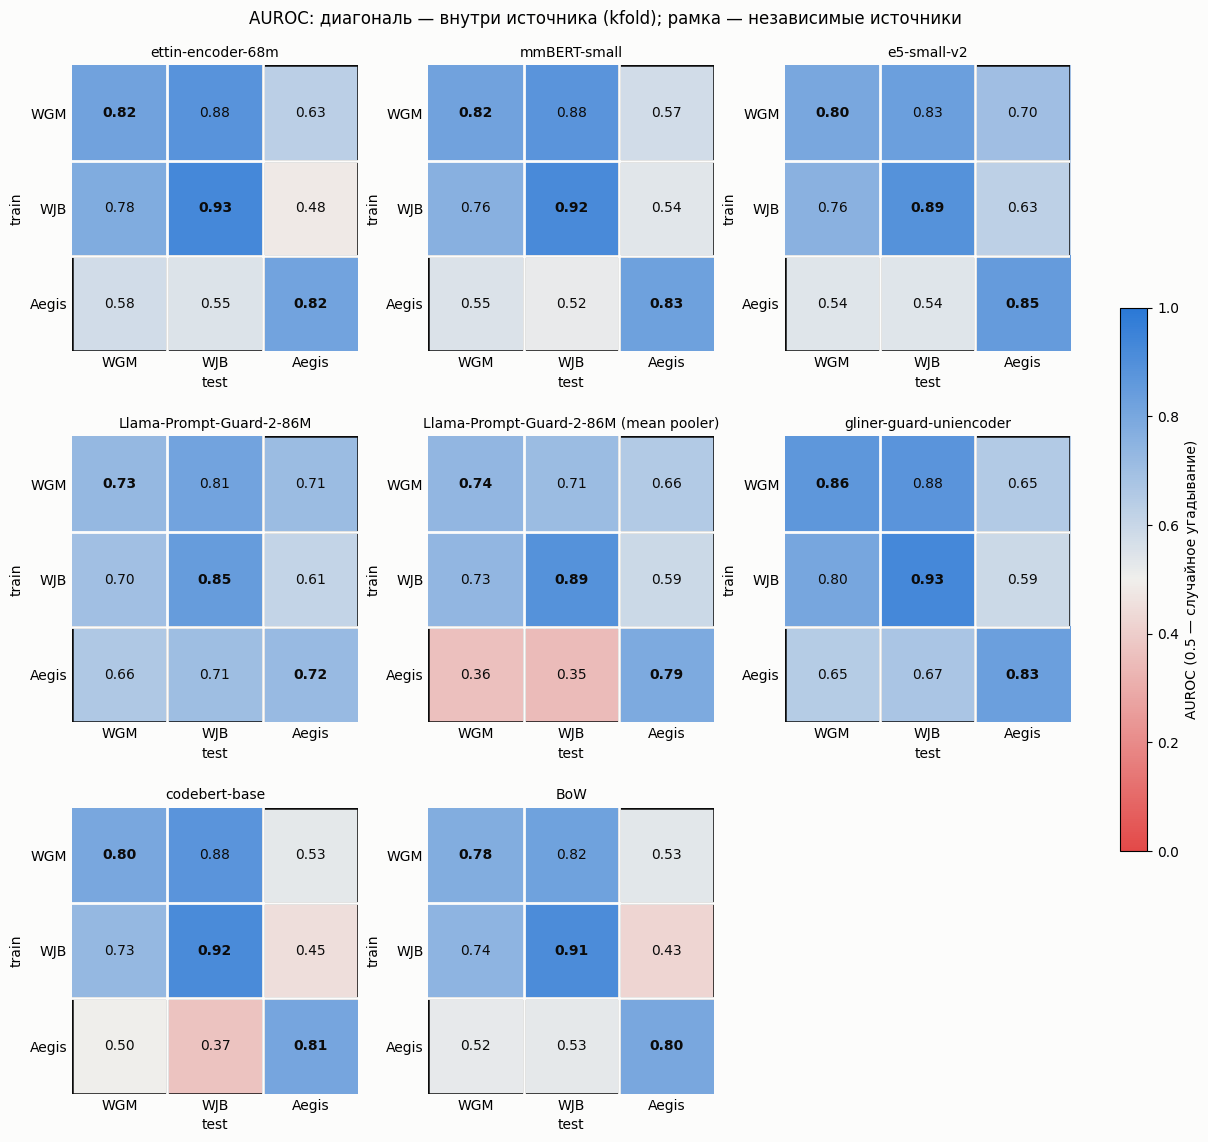

In [46]:
# Расходящаяся шкала вокруг случайного угадывания: красный < 0.5 < синий, серый ровно на 0.5
SURFACE_COLOR = "#fcfcfb"
TEXT_COLOR = "#0b0b0b"
AUROC_CMAP = LinearSegmentedColormap.from_list("auroc", ["#e34948", "#f0efec", "#2a78d6"])


def get_auroc_matrix(feature_set: str) -> np.ndarray:
    """Строки — источник обучения, столбцы — источник оценки; диагональ — kfold внутри источника."""
    return np.array([
        [
            IN_SOURCE[(feature_set, test_source)]["auroc (mean)"]
            if train_source == test_source
            else TRANSFER[(feature_set, train_source, test_source)]["auroc"]
            for test_source in SOURCE_NAMES
        ]
        for train_source in SOURCE_NAMES
    ])


def plot_transfer_matrices(feature_sets: Sequence[str] = TRANSFER_FEATURE_SETS, columns: int = 3):
    rows = math.ceil(len(feature_sets) / columns)
    figure, axes = plt.subplots(
        rows, columns,
        figsize=(4.0 * columns, 3.8 * rows),
        squeeze=False,
        layout="constrained",
        facecolor=SURFACE_COLOR,
    )
    tick_labels = [SOURCE_SHORT_NAMES[source_name] for source_name in SOURCE_NAMES]
    ticks = np.arange(len(SOURCE_NAMES))

    for axis, feature_set in zip(axes.flat, feature_sets):
        matrix = get_auroc_matrix(feature_set)
        image = axis.imshow(matrix, cmap=AUROC_CMAP, vmin=0.0, vmax=1.0)

        for row in ticks:
            for column in ticks:
                # рамка на клетках, где источники независимы (WildTeaming vs Aegis)
                independent = (row != column) and (
                    SOURCE_FRAMEWORK[SOURCE_NAMES[row]] != SOURCE_FRAMEWORK[SOURCE_NAMES[column]]
                )
                if independent:
                    axis.add_patch(plt.Rectangle((column - 0.5, row - 0.5), 1, 1, fill=False,
                                                 edgecolor=TEXT_COLOR, linewidth=1.8))
                axis.text(
                    column, row, f"{matrix[row, column]:.2f}",
                    ha="center", va="center", color=TEXT_COLOR, fontsize=10,
                    fontweight="bold" if row == column else "normal",
                )

        axis.set_xticks(ticks, tick_labels)
        axis.set_yticks(ticks, tick_labels)
        axis.set_xlabel("test")
        axis.set_ylabel("train")
        axis.set_title(feature_set, fontsize=10)

        axis.set_xticks(ticks[:-1] + 0.5, minor=True)
        axis.set_yticks(ticks[:-1] + 0.5, minor=True)
        axis.grid(which="minor", color=SURFACE_COLOR, linewidth=2)
        axis.tick_params(which="both", length=0)
        for spine in axis.spines.values():
            spine.set_visible(False)

    for axis in axes.flat[len(feature_sets):]:
        axis.set_visible(False)

    figure.colorbar(image, ax=axes.ravel().tolist(), shrink=0.5, label="AUROC (0.5 — случайное угадывание)")
    figure.suptitle("AUROC: диагональ — внутри источника (kfold); рамка — независимые источники")
    plt.close(figure)
    return figure


plot_transfer_matrices()

# Визуализация

t-SNE по всем трём источникам сразу: сырые эмбеддинги с L2-нормировкой, как в `visual_clust.ipynb`.
Кластеризация не делается. Показаны три модели из семи (`TSNE_MODELS`) — две лучшие по переносу и
Prompt-Guard как контраст; на семи панелях картинка была нечитаемой, а выводы одинаковые.

t-SNE сохраняет локальные соседства, но расстояния между группами точек и их размеры на картинке не
интерпретируются. Главный вопрос к этим проекциям: группируются ли точки сильнее по источнику, чем по
классу.

In [47]:
CLASS_COLORS = {"benign": "#2a78d6", "harmful": "#eb6834"}
SOURCE_COLORS = dict(zip(SOURCE_NAMES, ("#2a78d6", "#eb6834", "#1baf7a")))


def get_points(embeddings: torch.Tensor) -> np.ndarray:
    """Матрица (n, d) после L2-нормировки."""
    return F.normalize(embeddings, p=2, dim=0).detach().to(device="cpu", dtype=torch.float32).T.numpy()


def get_tsne_projections(embeddings_by_model: dict[str, torch.Tensor]) -> dict[str, np.ndarray]:
    projections = {}
    for name, matrix in embeddings_by_model.items():
        points = get_points(matrix)
        projections[name] = TSNE(
            n_components=2, perplexity=min(30.0, (points.shape[0] - 1) / 3),
            init="pca", learning_rate="auto", random_state=SEED,
        ).fit_transform(points)
        print(f"{name}: готово")
    return projections


def plot_projections(
        projections: dict[str, np.ndarray],
        labels: np.ndarray,
        colors: dict[str, str],
        title: str,
        columns: int = 3,
        point_size: float = 7.0,
):
    rows = math.ceil(len(projections) / columns)
    figure, axes = plt.subplots(
        rows, columns,
        figsize=(4.8 * columns, 4.4 * rows),
        squeeze=False,
        facecolor=SURFACE_COLOR,
    )

    for axis, (name, projection) in zip(axes.flat, projections.items()):
        for value, color in colors.items():
            mask = labels == value
            axis.scatter(
                projection[mask, 0], projection[mask, 1],
                s=point_size, alpha=0.55, linewidths=0, color=color, label=value,
            )
        axis.set_title(name, fontsize=10)
        axis.set_xticks([])
        axis.set_yticks([])
        axis.grid(alpha=0.2)

    axes.flat[0].legend(markerscale=2.5, fontsize=8)
    for axis in axes.flat[len(projections):]:
        axis.set_visible(False)

    figure.suptitle(title)
    figure.tight_layout()
    plt.close(figure)
    return figure


# Три представителя вместо всех семи: две лучшие модели по переносу и Prompt-Guard как контраст
# (у него пространство схлопнуто в 1-2 измерения, и это видно на проекции)
PREFERRED_TSNE_MODELS = ("gliner-guard-uniencoder", "e5-small-v2", "Llama-Prompt-Guard-2-86M")
TSNE_MODELS = tuple(name for name in PREFERRED_TSNE_MODELS if name in EMBEDDER_TYPES) or tuple(EMBEDDER_TYPES)[:3]

# Порядок точек совпадает с EMBEDDINGS[...]["all"]: источник за источником, внутри — benign, затем harmful
TSNE_EMBEDDINGS = {
    embedder: torch.cat([EMBEDDINGS[embedder][source_name]["all"] for source_name in SOURCE_NAMES], dim=1)
    for embedder in TSNE_MODELS
}
TSNE_CLASSES = np.concatenate([
    np.array(["benign"] * BENIGN[source_name].height + ["harmful"] * HARMFUL[source_name].height)
    for source_name in SOURCE_NAMES
])
TSNE_SOURCES = np.concatenate([
    np.array([source_name] * (BENIGN[source_name].height + HARMFUL[source_name].height))
    for source_name in SOURCE_NAMES
])

TSNE_PROJECTIONS = get_tsne_projections(TSNE_EMBEDDINGS)

gliner-guard-uniencoder: готово
e5-small-v2: готово
Llama-Prompt-Guard-2-86M: готово


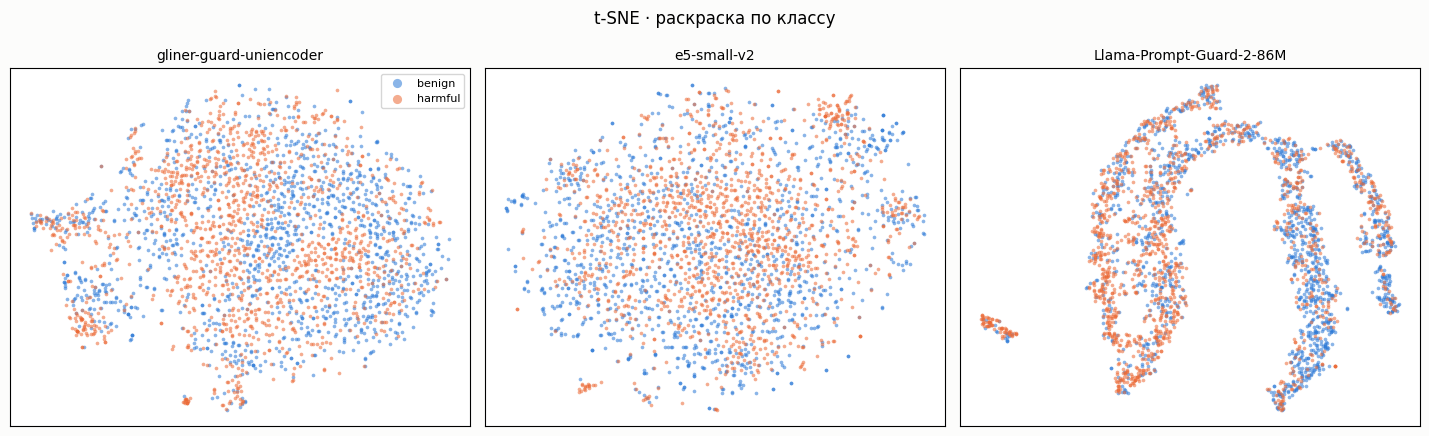

In [48]:
plot_projections(TSNE_PROJECTIONS, TSNE_CLASSES, CLASS_COLORS, "t-SNE · раскраска по классу")

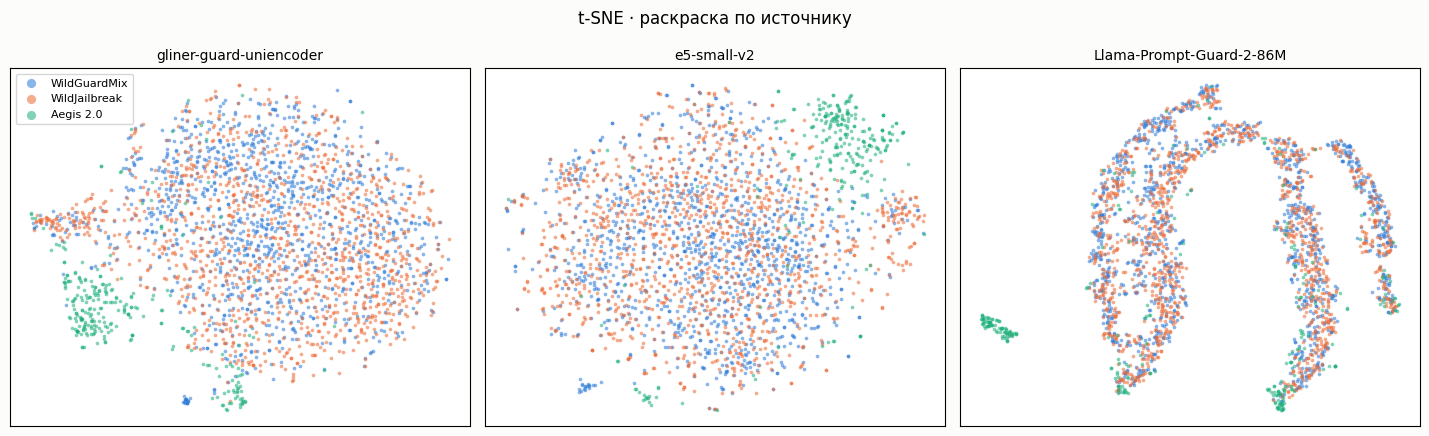

In [49]:
plot_projections(TSNE_PROJECTIONS, TSNE_SOURCES, SOURCE_COLORS, "t-SNE · раскраска по источнику")

# Выводы

> **Откуда числа.** Таблицы ниже — с полного прогона **до** улучшений этой версии блокнота: тогда Aegis
> брался как есть (166/167 на класс, без выравнивания по длине), а в таблице переноса участвовал
> бейзлайн `prompt len`. Что изменилось с тех пор: Aegis выровнен по длине (пар стало меньше), длина
> убрана из переноса, добавлена нижняя граница на перемешанных метках, спектры PCA и три таблицы
> расстояний убраны, t-SNE сведён к трём моделям.
>
> **Что из выводов устойчиво:** всё, что опирается на WildGuardMix и на сравнение с BoW в одинаковых
> условиях (пункты 1, 3, 4 и раздел про геометрию) — выравнивание Aegis на них не влияет.
> **Что надо перепроверить после перезапуска:** любые числа по Aegis и перенос на него (пункт 2), потому
> что часть разделимости там объяснялась разницей в длине, которую мы теперь и убрали.

## Главное

1. **Внутри WildGuardMix эмбеддинги впервые обгоняют лексику.** gliner-guard даёт AUROC 0.858 против
   0.771 у BoW (+0.087), длина при этом бесполезна (0.518). Это единственный из проверенных источников,
   где разделимость не объясняется поверхностными признаками.
2. **На честном тесте переноса работают только две модели.** WildGuardMix → Aegis (независимые
   источники): gliner-guard **0.750**, e5-small **0.722**, тогда как BoW — **0.473, ниже случайного
   угадывания**. То есть направление, найденное на WildGuardMix, переносится на независимый источник,
   а лексическое — нет. Этот пункт и нужно перепроверить после выравнивания Aegis по длине.
3. **CodeBERT на этих данных бесполезен.** В среднем по четырём независимым парам переноса он даёт
   0.42 — хуже BoW (0.45). На WJB → Aegis — 0.342, заметно ниже случайного. Код-специфичный энкодер не
   помогает, потому что срезы фактически про кибербезопасность, а не про написание кода.
4. **Внутри WildJailbreak разделимость лексическая.** BoW 0.920 против 0.931 у лучшего энкодера —
   разница в пределах шума. Этот источник годится как цель переноса, но не как доказательство
   семантики.

## Внутри источника (10-fold с группировкой по исходнику)

| набор признаков | WGM | WJB | Aegis |
|---|---|---|---|
| gliner-guard-uniencoder | **0.858** | 0.927 | 0.880 |
| ettin-encoder-68m | 0.814 | **0.931** | 0.891 |
| mmBERT-small | 0.810 | 0.918 | 0.870 |
| e5-small-v2 | 0.801 | 0.888 | **0.913** |
| codebert-base | 0.765 | 0.914 | 0.862 |
| Llama-Prompt-Guard-2 (mean pooler) | 0.764 | 0.856 | 0.871 |
| Llama-Prompt-Guard-2 (CLS) | 0.731 | 0.826 | 0.831 |
| **BoW** | **0.771** | **0.920** | **0.848** |
| prompt len | 0.518 | 0.606 | 0.645 |

Запас эмбеддингов над BoW: **+0.087 на WGM**, +0.011 на WJB (нет), +0.065 на Aegis. Бейзлайн длины
низкий везде — в отличие от отклонённых источников, где он доходил до 0.89.

## Перенос между источниками

Честный тест — только клетки с Aegis (в тепловой карте обведены рамкой).

| признаки | WGM → Aegis | Aegis → WGM | WJB → Aegis | Aegis → WJB | среднее |
|---|---|---|---|---|---|
| gliner-guard | **0.750** | **0.646** | 0.534 | 0.487 | **0.604** |
| e5-small-v2 | 0.722 | 0.560 | **0.610** | 0.514 | **0.602** |
| Prompt-Guard-2 (CLS) | 0.628 | 0.530 | 0.449 | 0.532 | 0.535 |
| ettin-encoder-68m | 0.600 | 0.585 | 0.414 | **0.535** | 0.534 |
| mmBERT-small | 0.641 | 0.494 | 0.435 | 0.486 | 0.514 |
| **BoW** | 0.473 | 0.480 | 0.486 | 0.364 | **0.451** |
| Prompt-Guard-2 (mean pooler) | 0.514 | 0.499 | 0.378 | 0.403 | 0.448 |
| codebert-base | 0.488 | 0.442 | 0.342 | 0.393 | 0.416 |

Три наблюдения:

* **Обучать надо на WildGuardMix.** WGM → Aegis (0.49–0.75) систематически лучше, чем WJB → Aegis
  (0.34–0.61). Источник с меньшей лексической утечкой даёт более переносимое направление.
* **WGM ↔ WJB ничего не доказывает.** Там 0.73–0.89 и крошечные gap (−0.02…−0.06), но BoW переносится
  так же (0.81 / 0.74). Это перенос внутри одного фреймворка, завышенный по построению.
* **Асимметрия.** Aegis → WGM (0.44–0.65) хуже, чем WGM → Aegis. Aegis сильно меньше и смещён по
  форме, поэтому направление на нём выучивается хуже.

## Геометрия

* **Классы не образуют кластеров.** В WildGuardMix межклассовое расстояние равно внутриклассовому
  (ettin: cross 0.0128 против within 0.0127–0.0129). Отношение расстояния между центрами к
  внутриклассовому — 0.10–0.17 у текстовых энкодеров, то есть меньше, чем в RQ1 (0.19–0.35).
* **FDR ниже, чем в RQ1.** На WGM 0.38–1.12 (в RQ1 было 1.1–1.9). Это ожидаемо: adversarial-промпты
  обоих классов написаны в одном стиле, и намерение спрятано глубже.
* **Подпространства классов почти совпадают:** overlap 0.63–0.79 при случайном уровне 0.16–0.48
  (WGM/WJB). Классы живут в одном подпространстве и различаются сдвигом, а не направлением.
* **Llama-Prompt-Guard-2 снова схлопнут** в 1–2 компоненты на 90% дисперсии. При этом у него самое
  большое отношение расстояния между центрами (0.54–0.65) и самый низкий probe AUROC (0.73–0.83):
  центры разнесены, но разброс вдоль той же оси огромный.

## t-SNE

* **По источнику:** Aegis у всех энкодеров выделяется в отдельный остров, а WildGuardMix и
  WildJailbreak перемешаны полностью. Это визуальное подтверждение того, что они сделаны одним
  фреймворком, и что перенос между ними — не независимый тест.
* **По классу:** сплошных облаков нет, но структура видна — у ettin и mmBERT есть область с перевесом
  harmful, у gliner — центральная полоса harmful против периферии benign. Это согласуется с AUROC
  0.81–0.86: классы сдвинуты, но не разделены.
* **Llama-Prompt-Guard-2** даёт нитевидные дуги вместо облака — прямое следствие схлопывания в 1–2
  измерения.

## Ограничения

* **Aegis — единственный независимый источник.** До выравнивания benign там имел медианную длину
  999 символов против 121 у harmful (системные и ролевые промпты против коротких запросов). Именно
  поэтому добавлено выравнивание по длине; но и после него все выводы про «честный перенос» держатся
  на одном источнике из трёх.
* **Это кибербезопасность, а не код.** Доля подсреза «код» — около трети, и по выборочной проверке
  метка там в основном ложная (ролевые сюжеты, упоминающие скрипты). Поэтому вывод про CodeBERT — это
  вывод про кибер-сюжеты, а не приговор код-энкодерам в code-домене.
* **Aegis маленький**, и после выравнивания по длине стал ещё меньше; разброс по фолдам там доходил до
  0.18. Разница между соседними моделями на нём статистически не значима — для этого и добавлена
  нижняя граница на перемешанных метках.
* **Размеры выборок выровнены вручную**, чтобы BoW и AUROC были сравнимы между источниками: BoW растёт
  с объёмом обучающих данных.